In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Configuración estética
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

# 1. Cargar el dataset unificado
# Asumo que el archivo se llama 'eu_tourism_resilience_merged.csv'
try:
    df = pd.read_csv('eu_tourism_resilience_merged.csv')
    df['date'] = pd.to_datetime(df['date'])
    print("Dataset cargado. Países disponibles:", df['geo'].unique())
except:
    print("Asegúrate de que el archivo 'eu_tourism_resilience_merged.csv' esté en la misma carpeta.")

Asegúrate de que el archivo 'eu_tourism_resilience_merged.csv' esté en la misma carpeta.


In [10]:
print("Tus columnas reales son:", df.columns.tolist())

Tus columnas reales son: ['date', 'country', 'google_trends', 'wiki_views']


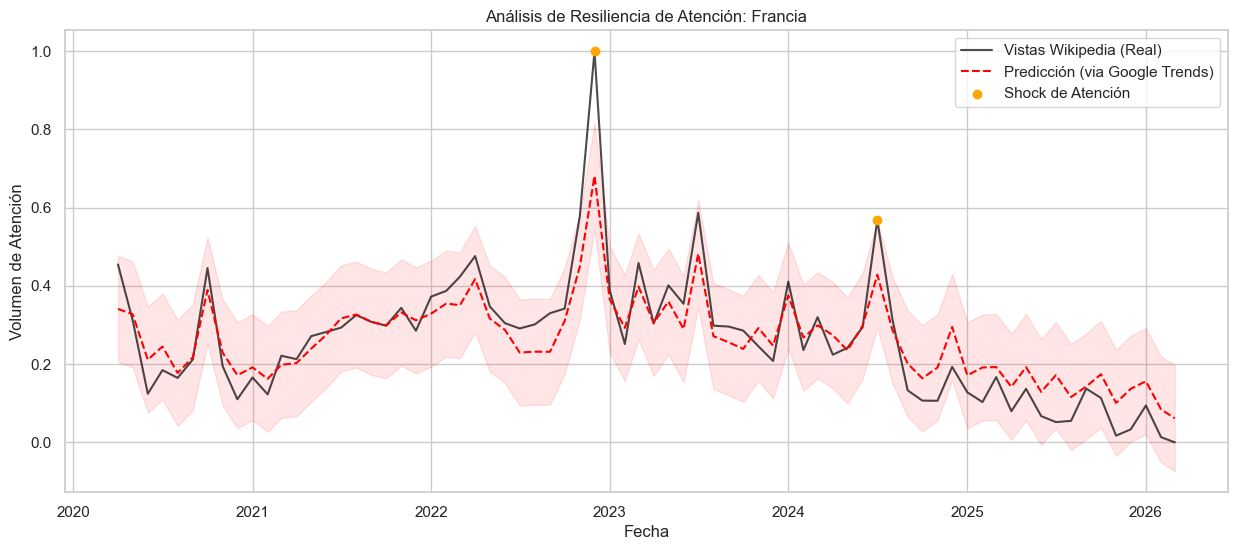

⚠️ No hay datos para el país: Albania


In [11]:
def analyze_country_resilience(df, country_name_in_csv, display_name):
    # 1. Ajuste de nombres de columnas según tu print
    col_country = 'country'
    col_date = 'date'
    col_target = 'wiki_views'    # Lo que queremos predecir (Realidad)
    col_feature = 'google_trends' # La señal que avisa (Google)

    # 2. Filtrar y ordenar
    data = df[df[col_country] == country_name_in_csv].sort_values(col_date).copy()
    
    if data.empty:
        print(f"⚠️ No hay datos para el país: {country_name_in_csv}")
        return None, None

    # 3. Crear variables de retraso (Lags)
    # Usamos Google Trends de hace 1, 2 y 3 meses
    for i in range(1, 4):
        data[f'lag_{i}'] = data[col_feature].shift(i)
    
    # Limpiamos los meses donde no hay histórico para el lag
    data = data.dropna(subset=['lag_1', 'lag_2', 'lag_3', col_target])
    
    if len(data) < 5:
        print(f"⚠️ Datos insuficientes para entrenar el modelo en {country_name_in_csv}")
        return None, None

    # 4. Entrenamiento del modelo
    features = ['lag_1', 'lag_2', 'lag_3']
    X = data[features]
    y = data[col_target]
    
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X, y)
    
    # 5. Predicción e Intervalos de Confianza (Incertidumbre)
    preds = model.predict(X)
    data['prediction'] = preds
    error_std = np.std(y - preds)
    data['upper_bound'] = preds + (1.96 * error_std)
    data['lower_bound'] = preds - (1.96 * error_std)
    
    # 6. Detección de Shocks
    data['is_shock'] = (data[col_target] > data['upper_bound']) | (data[col_target] < data['lower_bound'])
    
    # 7. Gráfico
    plt.figure(figsize=(15, 6))
    plt.plot(data[col_date], data[col_target], label='Vistas Wikipedia (Real)', color='black', alpha=0.7)
    plt.plot(data[col_date], data['prediction'], label='Predicción (via Google Trends)', color='red', linestyle='--')
    plt.fill_between(data[col_date], data['lower_bound'], data['upper_bound'], color='red', alpha=0.1)
    
    shocks = data[data['is_shock']]
    plt.scatter(shocks[col_date], shocks[col_target], color='orange', label='Shock de Atención', zorder=5)
    
    plt.title(f'Análisis de Resiliencia de Atención: {display_name}')
    plt.xlabel('Fecha')
    plt.ylabel('Volumen de Atención')
    plt.legend()
    plt.show()
    
    return data, model

# EJECUCIÓN (Asegúrate de que los nombres 'France' y 'Albania' coinciden con tu columna 'country')
res_fr, model_fr = analyze_country_resilience(df, 'France', 'Francia')
res_al, model_al = analyze_country_resilience(df, 'Albania', 'Albania')

C:\Users\cesia\AppData\Local\Temp\ipykernel_16656\3431801611.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_eurostat['date'] = pd.to_datetime(df_eurostat['date'])


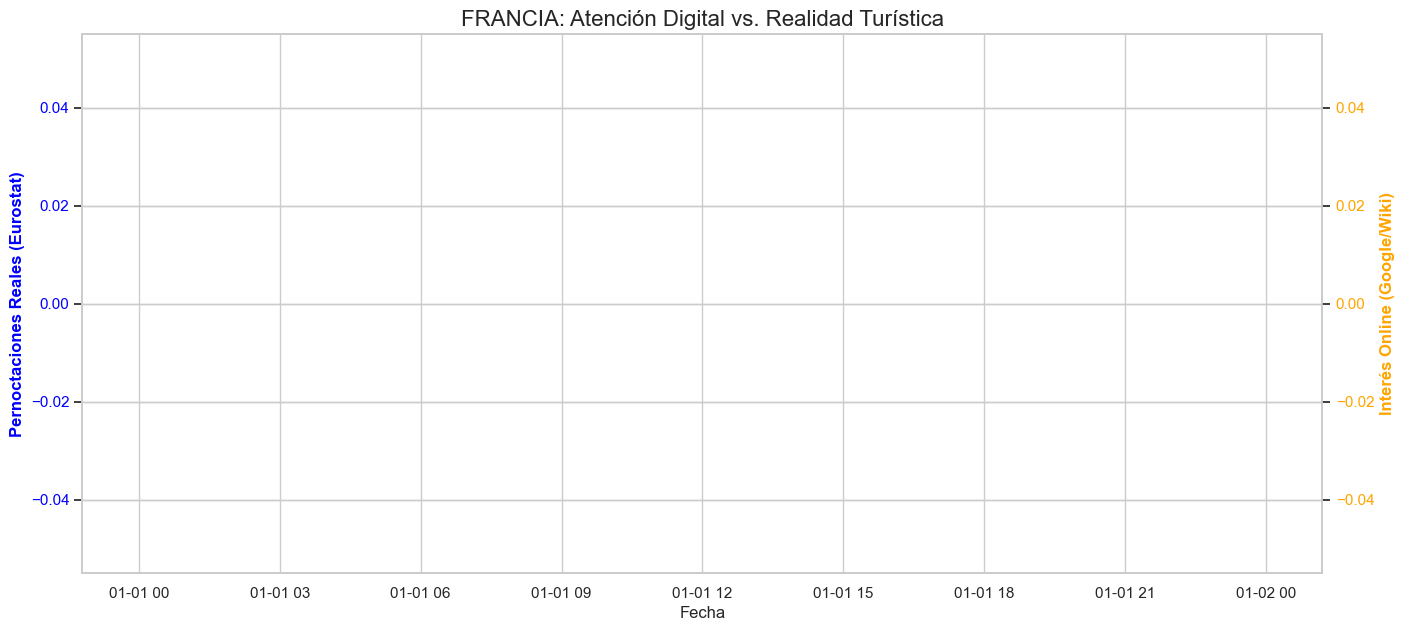

La correlación entre búsquedas y pernoctaciones en Francia es: nan


In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar el archivo de Eurostat (Realidad física)
df_eurostat = pd.read_csv('cleaned_tourism_data.csv')
df_eurostat['date'] = pd.to_datetime(df_eurostat['date'])

# Filtramos Francia, Extranjeros y Total Alojamientos
df_real_fr = df_eurostat[
    (df_eurostat['geo'] == 'FR') & 
    (df_eurostat['c_resid'] == 'FOR') & 
    (df_eurostat['nace_r2'] == 'I551-I553')
].copy()

# 2. Cargar vuestro archivo de tendencias (Atención online)
df_trends = pd.read_csv('eu_tourism_resilience_merged.csv')
df_trends['date'] = pd.to_datetime(df_trends['date'])
df_trends_fr = df_trends[df_trends['country'] == 'France'].copy()

# 3. Juntar ambos por fecha (Merge)
df_final_fr = pd.merge(df_real_fr, df_trends_fr, on='date', how='inner')

# 4. Gráfico de Doble Eje: ¿La atención predice las camas ocupadas?
fig, ax1 = plt.subplots(figsize=(16, 7))

# Eje 1: Realidad (Eurostat)
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Pernoctaciones Reales (Eurostat)', color='blue', fontweight='bold')
ax1.plot(df_final_fr['date'], df_final_fr['value'], color='blue', label='Nights Spent (Real)', linewidth=3)
ax1.tick_params(axis='y', labelcolor='blue')

# Eje 2: Atención (Google Trends / Wiki)
ax2 = ax1.twinx()
ax2.set_ylabel('Interés Online (Google/Wiki)', color='orange', fontweight='bold')
ax2.plot(df_final_fr['date'], df_final_fr['google_trends'], color='orange', label='Google Trends', linestyle='--')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('FRANCIA: Atención Digital vs. Realidad Turística', fontsize=16)
plt.show()

# 5. Calcular Correlación
corr = df_final_fr['value'].corr(df_final_fr['google_trends'])
print(f"La correlación entre búsquedas y pernoctaciones en Francia es: {corr:.2f}")

In [12]:
# EJECUCIÓN PARA ESPAÑA Y ALBANIA
# Asegúrate de que 'Spain' está escrito así en la columna 'country' de tu CSV
print("Analizando España (Destino Maduro/Estable)...")
res_es, model_es = analyze_country_resilience(df, 'Spain', 'España')

print("Analizando Albania (Destino Emergente/Viral)...")
res_al, model_al = analyze_country_resilience(df, 'Albania', 'Albania')

Analizando España (Destino Maduro/Estable)...
⚠️ No hay datos para el país: Spain
Analizando Albania (Destino Emergente/Viral)...
⚠️ No hay datos para el país: Albania


In [13]:
importances = pd.Series(model_al.feature_importances_, index=['Lag 1 mes', 'Lag 2 meses', 'Lag 3 meses'])
importances.plot(kind='barh', title='¿Qué mes de Google predice mejor el futuro?')

AttributeError: 'NoneType' object has no attribute 'feature_importances_'